In [1]:
import requests

url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/ilc_di03"

params = {
    "lang": "EN",
    "geo": "BG",
    "lastTimePeriod": 3
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

print("Dataset dimensions:", data["id"])
print("Dimension sizes:", data["size"])

Dataset dimensions: ['freq', 'age', 'sex', 'statinfo', 'unit', 'geo', 'time']
Dimension sizes: [1, 25, 3, 2, 3, 1, 3]


In [2]:
dimensions_to_check = ["age", "sex", "statinfo", "unit"]

for dimension_name in dimensions_to_check:
    print("\nDIMENSION:", dimension_name)
    print("Label:", data["dimension"][dimension_name]["label"])
    print(
        "Codes:",
        data["dimension"][dimension_name]["category"]["index"]
    )
    print(
        "Labels:",
        data["dimension"][dimension_name]["category"]["label"]
    )


DIMENSION: age
Label: Age class
Codes: {'TOTAL': 0, 'Y_LT6': 1, 'Y6-10': 2, 'Y6-11': 3, 'Y11-15': 4, 'Y12-17': 5, 'Y_LT16': 6, 'Y16-24': 7, 'Y16-64': 8, 'Y_GE16': 9, 'Y_LT18': 10, 'Y18-24': 11, 'Y18-64': 12, 'Y_GE18': 13, 'Y25-49': 14, 'Y25-54': 15, 'Y50-64': 16, 'Y55-64': 17, 'Y_LT60': 18, 'Y_GE60': 19, 'Y_LT65': 20, 'Y65-74': 21, 'Y_GE65': 22, 'Y_LT75': 23, 'Y_GE75': 24}
Labels: {'TOTAL': 'Total', 'Y_LT6': 'Less than 6 years', 'Y6-10': 'From 6 to 10 years', 'Y6-11': 'From 6 to 11 years', 'Y11-15': 'From 11 to 15 years', 'Y12-17': 'From 12 to 17 years', 'Y_LT16': 'Less than 16 years', 'Y16-24': 'From 16 to 24 years', 'Y16-64': 'From 16 to 64 years', 'Y_GE16': '16 years or over', 'Y_LT18': 'Less than 18 years', 'Y18-24': 'From 18 to 24 years', 'Y18-64': 'From 18 to 64 years', 'Y_GE18': '18 years or over', 'Y25-49': 'From 25 to 49 years', 'Y25-54': 'From 25 to 54 years', 'Y50-64': 'From 50 to 64 years', 'Y55-64': 'From 55 to 64 years', 'Y_LT60': 'Less than 60 years', 'Y_GE60': '60 year

In [3]:
print(data["dimension"]["time"]["category"]["index"])
print(data["dimension"]["time"]["category"]["label"])

{'2023': 0, '2024': 1, '2025': 2}
{'2023': '2023', '2024': '2024', '2025': '2025'}


In [4]:
import requests

url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/ilc_di03"

params = {
    "lang": "EN",
    "geo": "BG",
    "lastTimePeriod": 3
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

print("Dataset dimensions:", data["id"])
print("Dimension sizes:", data["size"])

Dataset dimensions: ['freq', 'age', 'sex', 'statinfo', 'unit', 'geo', 'time']
Dimension sizes: [1, 25, 3, 2, 3, 1, 3]


In [5]:
income_params = {
    "lang": "EN",
    "age": "TOTAL",
    "sex": "T",
    "statinfo": "MED_EI",
    "unit": "PPS",
    "geo": "BG",
    "lastTimePeriod": 3
}

income_response = requests.get(url, params=income_params)
income_response.raise_for_status()

income_data = income_response.json()

print("Dimensions:", income_data["id"])
print("Sizes:", income_data["size"])
print("Time:", income_data["dimension"]["time"]["category"]["index"])
print("Values:", income_data["value"])

Dimensions: ['freq', 'age', 'sex', 'statinfo', 'unit', 'geo', 'time']
Sizes: [1, 1, 1, 1, 1, 1, 3]
Time: {'2023': 0, '2024': 1, '2025': 2}
Values: {'0': 11155, '1': 13079, '2': 14843}


In [6]:
import pandas as pd

years = income_data["dimension"]["time"]["category"]["index"]
values = income_data["value"]

income_rows = []

for year, position in years.items():
    income_rows.append({
        "year": int(year),
        "geo": "BG",
        "income_pps": values[str(position)]
    })

income_df = pd.DataFrame(income_rows)

print(income_df)

   year geo  income_pps
0  2023  BG       11155
1  2024  BG       13079
2  2025  BG       14843


In [7]:
geos = ["BG", "RO", "DE", "EU27_2020"]

print(geos)

['BG', 'RO', 'DE', 'EU27_2020']


In [8]:
for geo in geos:
    income_params = {
        "lang": "EN",
        "age": "TOTAL",
        "sex": "T",
        "statinfo": "MED_EI",
        "unit": "PPS",
        "geo": geo,
        "lastTimePeriod": 3
    }

    income_response = requests.get(url, params=income_params)
    income_response.raise_for_status()

    income_data = income_response.json()

    print("Geo:", geo)
    print("Time:", income_data["dimension"]["time"]["category"]["index"])
    print("Values:", income_data["value"])
    print()

Geo: BG
Time: {'2023': 0, '2024': 1, '2025': 2}
Values: {'0': 11155, '1': 13079, '2': 14843}

Geo: RO
Time: {'2023': 0, '2024': 1, '2025': 2}
Values: {'0': 11084, '1': 13023, '2': 12861}

Geo: DE
Time: {'2023': 0, '2024': 1, '2025': 2}
Values: {'0': 24086, '1': 25192, '2': 26594}

Geo: EU27_2020
Time: {'2023': 0, '2024': 1, '2025': 2}
Values: {'0': 19903, '1': 21245, '2': 22638}



In [9]:
all_income_rows = []

for geo in geos:
    income_params = {
        "lang": "EN",
        "age": "TOTAL",
        "sex": "T",
        "statinfo": "MED_EI",
        "unit": "PPS",
        "geo": geo,
        "lastTimePeriod": 3
    }

    income_response = requests.get(url, params=income_params)
    income_response.raise_for_status()

    income_data = income_response.json()

    years = income_data["dimension"]["time"]["category"]["index"]
    values = income_data["value"]

    for year, position in years.items():
        all_income_rows.append({
            "year": int(year),
            "geo": geo,
            "income_pps": values[str(position)]
        })

all_income_df = pd.DataFrame(all_income_rows)

print(all_income_df)

    year        geo  income_pps
0   2023         BG       11155
1   2024         BG       13079
2   2025         BG       14843
3   2023         RO       11084
4   2024         RO       13023
5   2025         RO       12861
6   2023         DE       24086
7   2024         DE       25192
8   2025         DE       26594
9   2023  EU27_2020       19903
10  2024  EU27_2020       21245
11  2025  EU27_2020       22638


In [10]:
all_income_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   year        12 non-null     int64
 1   geo         12 non-null     str  
 2   income_pps  12 non-null     int64
dtypes: int64(2), str(1)
memory usage: 420.0 bytes


In [11]:
duplicate_count = all_income_df.duplicated(
    subset=["year", "geo"]
).sum()

print("Duplicate year-geo rows:", duplicate_count)

Duplicate year-geo rows: 0


In [12]:
income_rows_to_load = list(
    all_income_df.itertuples(index=False, name=None)
)

print(income_rows_to_load)

[(2023, 'BG', 11155), (2024, 'BG', 13079), (2025, 'BG', 14843), (2023, 'RO', 11084), (2024, 'RO', 13023), (2025, 'RO', 12861), (2023, 'DE', 24086), (2024, 'DE', 25192), (2025, 'DE', 26594), (2023, 'EU27_2020', 19903), (2024, 'EU27_2020', 21245), (2025, 'EU27_2020', 22638)]


In [13]:
from pathlib import Path
import sys

current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.db import get_connection

print("Database connection function imported successfully.")

Database connection function imported successfully.


In [14]:
connection = get_connection()

print(type(connection))

<class 'mariadb.connections.Connection'>


In [15]:
cursor = connection.cursor()

print(type(cursor))

<class 'mariadb.cursors.Cursor'>


In [16]:
upsert_sql = """
INSERT INTO income_pps (year, geo, income_pps)
VALUES (?, ?, ?)
ON DUPLICATE KEY UPDATE
    income_pps = VALUES(income_pps)
"""

print(upsert_sql)


INSERT INTO income_pps (year, geo, income_pps)
VALUES (?, ?, ?)
ON DUPLICATE KEY UPDATE
    income_pps = VALUES(income_pps)



In [17]:
cursor.executemany(upsert_sql, income_rows_to_load)

connection.commit()

print("Income rows loaded:", cursor.rowcount)

Income rows loaded: 0


In [18]:
cursor.execute("SELECT COUNT(*) FROM income_pps")

row_count = cursor.fetchone()[0]

print("Rows currently in income_pps:", row_count)

Rows currently in income_pps: 12


In [19]:
cursor.execute("""
SELECT
    year,
    geo,
    income_pps
FROM income_pps
ORDER BY geo, year;
""")

database_rows = cursor.fetchall()

for row in database_rows:
    print(row)

(2023, 'BG', Decimal('11155.00'))
(2024, 'BG', Decimal('13079.00'))
(2025, 'BG', Decimal('14843.00'))
(2023, 'DE', Decimal('24086.00'))
(2024, 'DE', Decimal('25192.00'))
(2025, 'DE', Decimal('26594.00'))
(2023, 'EU27_2020', Decimal('19903.00'))
(2024, 'EU27_2020', Decimal('21245.00'))
(2025, 'EU27_2020', Decimal('22638.00'))
(2023, 'RO', Decimal('11084.00'))
(2024, 'RO', Decimal('13023.00'))
(2025, 'RO', Decimal('12861.00'))


In [20]:
db_income_df = pd.DataFrame(
    database_rows,
    columns=["year", "geo", "income_pps"]
)

print(db_income_df)

    year        geo income_pps
0   2023         BG   11155.00
1   2024         BG   13079.00
2   2025         BG   14843.00
3   2023         DE   24086.00
4   2024         DE   25192.00
5   2025         DE   26594.00
6   2023  EU27_2020   19903.00
7   2024  EU27_2020   21245.00
8   2025  EU27_2020   22638.00
9   2023         RO   11084.00
10  2024         RO   13023.00
11  2025         RO   12861.00


In [21]:
source_check_df = all_income_df.copy()
db_check_df = db_income_df.copy()

source_check_df["income_pps"] = source_check_df["income_pps"].astype("int64")
db_check_df["income_pps"] = db_check_df["income_pps"].astype("int64")

source_check_df = source_check_df.sort_values(
    ["geo", "year"]
).reset_index(drop=True)

db_check_df = db_check_df.sort_values(
    ["geo", "year"]
).reset_index(drop=True)

print("Source and database match:", source_check_df.equals(db_check_df))

Source and database match: True


In [22]:
source_check_df = all_income_df.copy()
db_check_df = db_income_df.copy()

source_check_df["income_pps"] = source_check_df["income_pps"].astype("int64")
db_check_df["income_pps"] = db_check_df["income_pps"].astype("int64")

source_check_df = source_check_df.sort_values(
    ["geo", "year"]
).reset_index(drop=True)

db_check_df = db_check_df.sort_values(
    ["geo", "year"]
).reset_index(drop=True)

print("Source and database match:", source_check_df.equals(db_check_df))

Source and database match: True


In [23]:
cursor.close()
connection.close()

print("Database connection closed.")

Database connection closed.


## Affordability analysis

Read the final affordability-change results from MariaDB into pandas for validation and visualization.

In [24]:
from pathlib import Path
import sys

current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.db import get_connection

print("Database connection function imported successfully.")

Database connection function imported successfully.


In [25]:
connection = get_connection()
cursor = connection.cursor()

print("Database connection opened.")

Database connection opened.


In [26]:
affordability_sql = """
WITH annual_hicp AS (
    SELECT
        YEAR(month) AS hicp_year,
        geo,
        AVG(hicp_index) AS avg_hicp_food_index
    FROM hicp_food_index
    WHERE YEAR(month) BETWEEN 2022 AND 2024
    GROUP BY YEAR(month), geo
),

growth_rates AS (
    SELECT
        income_pps.year AS income_survey_year,
        income_pps.year - 1 AS income_reference_year,
        annual_hicp.geo,

        ROUND(
            (
                annual_hicp.avg_hicp_food_index /
                LAG(annual_hicp.avg_hicp_food_index) OVER (
                    PARTITION BY annual_hicp.geo
                    ORDER BY income_pps.year
                )
                - 1
            ) * 100,
            2
        ) AS food_hicp_change_pct,

        ROUND(
            (
                income_pps.income_pps /
                LAG(income_pps.income_pps) OVER (
                    PARTITION BY income_pps.geo
                    ORDER BY income_pps.year
                )
                - 1
            ) * 100,
            2
        ) AS income_pps_change_pct

    FROM annual_hicp
    JOIN income_pps
        ON annual_hicp.hicp_year = income_pps.year - 1
        AND annual_hicp.geo = income_pps.geo
),

affordability AS (
    SELECT
        income_reference_year,
        geo,
        food_hicp_change_pct,
        income_pps_change_pct,
        ROUND(
            income_pps_change_pct - food_hicp_change_pct,
            2
        ) AS affordability_change_proxy_pp
    FROM growth_rates
)

SELECT *
FROM affordability
WHERE affordability_change_proxy_pp IS NOT NULL
ORDER BY income_reference_year, geo;
"""

cursor.execute(affordability_sql)

affordability_rows = cursor.fetchall()

print("Rows fetched:", len(affordability_rows))
print(affordability_rows[0])

Rows fetched: 8
(2023, 'BG', Decimal('14.05'), Decimal('17.25'), Decimal('3.20'))


In [27]:
affordability_df = pd.DataFrame(
    affordability_rows,
    columns=[
        "income_reference_year",
        "geo",
        "food_hicp_change_pct",
        "income_pps_change_pct",
        "affordability_change_proxy_pp"
    ]
)

print(affordability_df)

   income_reference_year        geo food_hicp_change_pct  \
0                   2023         BG                14.05   
1                   2023         DE                12.70   
2                   2023  EU27_2020                12.65   
3                   2023         RO                14.63   
4                   2024         BG                 2.78   
5                   2024         DE                 2.34   
6                   2024  EU27_2020                 2.32   
7                   2024         RO                 2.89   

  income_pps_change_pct affordability_change_proxy_pp  
0                 17.25                          3.20  
1                  4.59                         -8.11  
2                  6.74                         -5.91  
3                 17.49                          2.86  
4                 13.49                         10.71  
5                  5.57                          3.23  
6                  6.56                          4.24  
7          

In [28]:
import pandas as pd

print("pandas imported successfully.")

pandas imported successfully.


In [29]:
affordability_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   income_reference_year          8 non-null      int64 
 1   geo                            8 non-null      str   
 2   food_hicp_change_pct           8 non-null      object
 3   income_pps_change_pct          8 non-null      object
 4   affordability_change_proxy_pp  8 non-null      object
dtypes: int64(1), object(3), str(1)
memory usage: 452.0+ bytes


In [30]:
affordability_df["food_hicp_change_pct"] = affordability_df[
    "food_hicp_change_pct"
].astype("float64")

affordability_df["income_pps_change_pct"] = affordability_df[
    "income_pps_change_pct"
].astype("float64")

affordability_df["affordability_change_proxy_pp"] = affordability_df[
    "affordability_change_proxy_pp"
].astype("float64")

affordability_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   income_reference_year          8 non-null      int64  
 1   geo                            8 non-null      str    
 2   food_hicp_change_pct           8 non-null      float64
 3   income_pps_change_pct          8 non-null      float64
 4   affordability_change_proxy_pp  8 non-null      float64
dtypes: float64(3), int64(1), str(1)
memory usage: 452.0 bytes


In [31]:
cursor.close()
connection.close()

print("Database connection closed.")

Database connection closed.


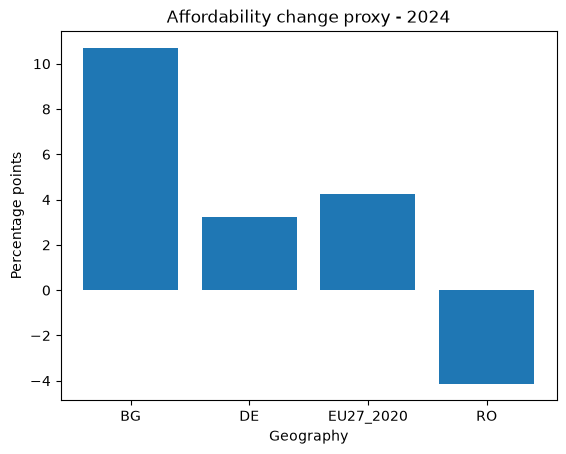

In [32]:
import matplotlib.pyplot as plt

affordability_2024 = affordability_df[
    affordability_df["income_reference_year"] == 2024
]

plt.bar(
    affordability_2024["geo"],
    affordability_2024["affordability_change_proxy_pp"]
)

plt.title("Affordability change proxy - 2024")
plt.xlabel("Geography")
plt.ylabel("Percentage points")

plt.show()

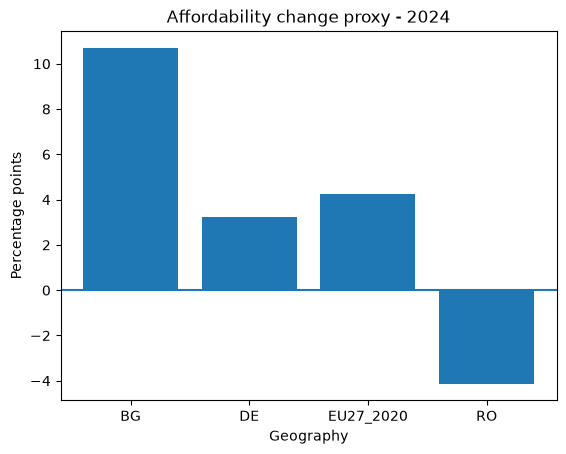

In [33]:
import matplotlib.pyplot as plt

affordability_2024 = affordability_df[
    affordability_df["income_reference_year"] == 2024
]

plt.bar(
    affordability_2024["geo"],
    affordability_2024["affordability_change_proxy_pp"]
)

plt.axhline(y=0)

plt.title("Affordability change proxy - 2024")
plt.xlabel("Geography")
plt.ylabel("Percentage points")

plt.show()

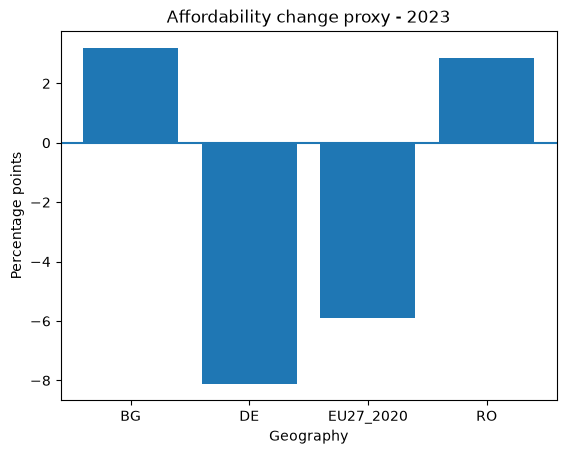

In [34]:
affordability_2023 = affordability_df[
    affordability_df["income_reference_year"] == 2023
]

plt.bar(
    affordability_2023["geo"],
    affordability_2023["affordability_change_proxy_pp"]
)

plt.axhline(y=0)

plt.title("Affordability change proxy - 2023")
plt.xlabel("Geography")
plt.ylabel("Percentage points")

plt.show()

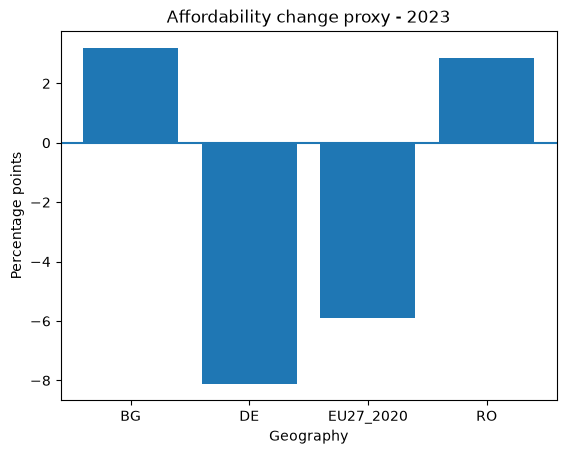

In [35]:
affordability_2023 = affordability_df[
    affordability_df["income_reference_year"] == 2023
]

plt.bar(
    affordability_2023["geo"],
    affordability_2023["affordability_change_proxy_pp"]
)

plt.axhline(y=0)

plt.title("Affordability change proxy - 2023")
plt.xlabel("Geography")
plt.ylabel("Percentage points")

plt.show()

In [36]:
comparison_df = affordability_df.pivot(
    index="geo",
    columns="income_reference_year",
    values="affordability_change_proxy_pp"
)

print(comparison_df)

income_reference_year  2023   2024
geo                               
BG                     3.20  10.71
DE                    -8.11   3.23
EU27_2020             -5.91   4.24
RO                     2.86  -4.13


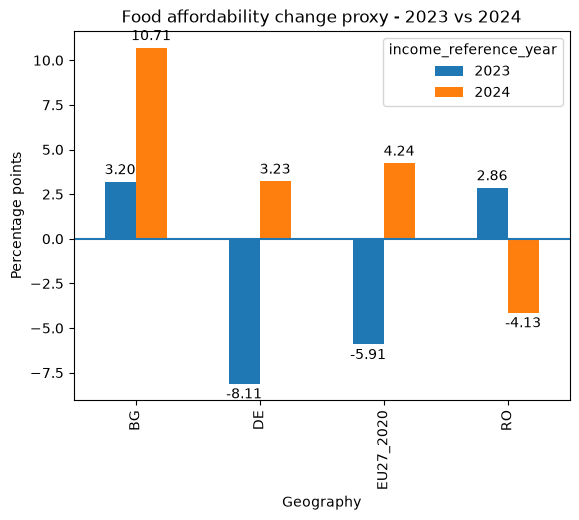

In [37]:
ax = comparison_df.plot.bar()

plt.axhline(y=0)

plt.title("Food affordability change proxy - 2023 vs 2024")
plt.xlabel("Geography")
plt.ylabel("Percentage points")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.show()

### Interpretation and methodological note

The affordability change proxy compares the annual growth of median equivalised
income in PPS with the annual growth of the food HICP:

**Affordability change proxy = income PPS growth − food HICP growth**

A positive value indicates that income in PPS increased faster than the food
price index during the corresponding income reference year. A negative value
indicates that food HICP increased faster than income in PPS.

For Bulgaria, the proxy was positive in both reference years:
- 2023: +3.20 percentage points
- 2024: +10.71 percentage points

This suggests an improvement in relative food affordability under this
simplified measure, particularly in 2024.

The indicator is a project-specific descriptive proxy and is not an official
Eurostat affordability indicator. It does not measure absolute food
affordability and should not be interpreted as evidence of causality.

Income data refer to median equivalised income expressed in PPS
(Purchasing Power Standard), while food-price dynamics are represented by
the HICP (Harmonised Index of Consumer Prices) for food.

## Data sources and references

### Data sources

- **Eurostat — HICP monthly data**
  - Dataset: `prc_hicp_minr`
  - Used for monthly food HICP data.
  - Food category: `CP01`
  - Unit: `I25` (2025 = 100)

- **Eurostat — Mean and median income by age and sex**
  - Dataset: `ilc_di03`
  - Indicator: Median equivalised income
  - Unit: PPS (Purchasing Power Standard)
  - Used for the income component of the affordability analysis.

### Academic context

Bai, Y., Alemu, R., Block, S. A., Headey, D., & Masters, W. A. (2021).
*Cost and affordability of nutritious diets at retail prices: Evidence from 177 countries.*
Food Policy, 99, 101983.
DOI: 10.1016/j.foodpol.2020.101983

Headey, D., Hirvonen, K., & Alderman, H. (2024).
*Estimating the cost and affordability of healthy diets: How much do methods matter?*
Food Policy, 126, 102654.
DOI: 10.1016/j.foodpol.2024.102654

### Methodological distinction

The academic publications above provide conceptual and methodological context for
food affordability analysis. The affordability change proxy used in this project
is not taken directly from either publication.

It is a project-specific descriptive measure calculated as:

**income PPS growth − food HICP growth**

Therefore, the results should be interpreted as changes in relative affordability
dynamics rather than as estimates of the official Cost and Affordability of a
Healthy Diet (CoAHD) indicator.

In [38]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\User\Desktop\Python Essentials\european_food_price_monitor


In [39]:
from src.db import get_connection
import pandas as pd

affordability_sql = """
WITH income_reference_year AS (
    SELECT
        year - 1 AS reference_year,
        geo,
        income_pps
    FROM income_pps
),

income_growth AS (
    SELECT
        reference_year,
        geo,
        income_pps,
        (
            (
                income_pps
                - LAG(income_pps) OVER (
                    PARTITION BY geo
                    ORDER BY reference_year
                )
            )
            /
            NULLIF(
                LAG(income_pps) OVER (
                    PARTITION BY geo
                    ORDER BY reference_year
                ),
                0
            )
        ) * 100 AS income_growth_pct
    FROM income_reference_year
),

annual_food_hicp AS (
    SELECT
        YEAR(month) AS year,
        geo,
        AVG(hicp_index) AS annual_food_hicp_index
    FROM hicp_food_index
    WHERE geo IN ('BG', 'DE', 'RO', 'EU27_2020')
    GROUP BY
        YEAR(month),
        geo
),

food_growth AS (
    SELECT
        year,
        geo,
        annual_food_hicp_index,
        (
            (
                annual_food_hicp_index
                - LAG(annual_food_hicp_index) OVER (
                    PARTITION BY geo
                    ORDER BY year
                )
            )
            /
            NULLIF(
                LAG(annual_food_hicp_index) OVER (
                    PARTITION BY geo
                    ORDER BY year
                ),
                0
            )
        ) * 100 AS food_hicp_growth_pct
    FROM annual_food_hicp
)

SELECT
    i.reference_year,
    i.geo,
    ROUND(i.income_growth_pct, 2) AS income_growth_pct,
    ROUND(f.food_hicp_growth_pct, 2) AS food_hicp_growth_pct,
    ROUND(
        i.income_growth_pct - f.food_hicp_growth_pct,
        2
    ) AS simple_difference_pp,
    ROUND(
        (
            (
                1 + i.income_growth_pct / 100
            )
            /
            (
                1 + f.food_hicp_growth_pct / 100
            )
            - 1
        ) * 100,
        2
    ) AS food_adjusted_income_growth_pct
FROM income_growth AS i
INNER JOIN food_growth AS f
    ON i.reference_year = f.year
    AND i.geo = f.geo
WHERE i.income_growth_pct IS NOT NULL
ORDER BY
    i.reference_year,
    i.geo;
"""

connection = get_connection()
cursor = connection.cursor()

cursor.execute(affordability_sql)

rows = cursor.fetchall()
columns = [column[0] for column in cursor.description]

affordability_df = pd.DataFrame(
    rows,
    columns=columns
)

cursor.close()
connection.close()

display(affordability_df)

,reference_year,geo,income_growth_pct,food_hicp_growth_pct,simple_difference_pp,food_adjusted_income_growth_pct
0,2023,BG,17.25,14.05,3.20,2.81
1,2023,DE,4.59,12.70,-8.11,-7.20
2,2023,EU27_2020,6.74,12.65,-5.91,-5.24
3,2023,RO,17.49,14.63,2.86,2.49
4,2024,BG,13.49,2.78,10.71,10.42
5,2024,DE,5.57,2.34,3.23,3.15
6,2024,EU27_2020,6.56,2.32,4.24,4.15
7,2024,RO,-1.24,2.89,-4.13,-4.02


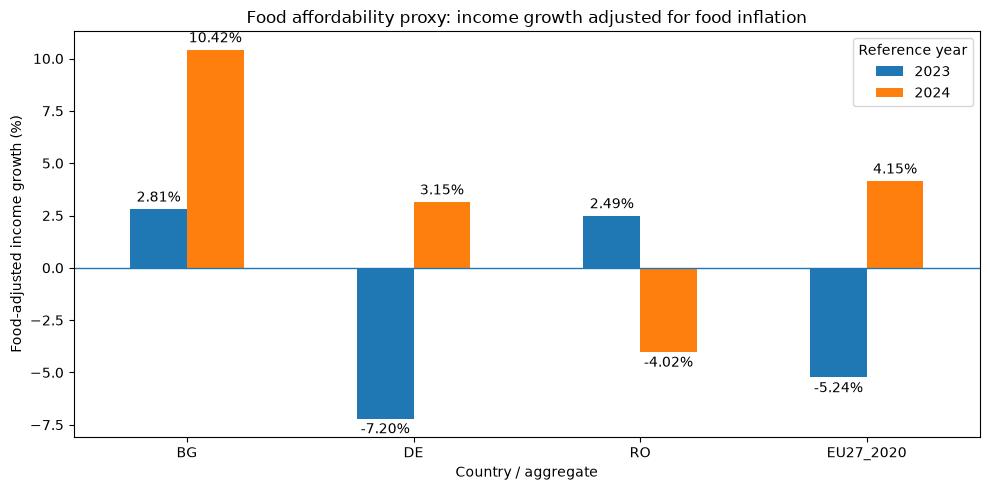

Saved to: C:\Users\User\Desktop\Python Essentials\european_food_price_monitor\outputs\figures\food_adjusted_income_growth.png


In [40]:
import matplotlib.pyplot as plt
from pathlib import Path

affordability_df["food_adjusted_income_growth_pct"] = (
    affordability_df["food_adjusted_income_growth_pct"].astype(float)
)

plot_df = affordability_df.pivot(
    index="geo",
    columns="reference_year",
    values="food_adjusted_income_growth_pct"
)

plot_df = plot_df.reindex(
    ["BG", "DE", "RO", "EU27_2020"]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.axhline(0, linewidth=1)

ax.set_xlabel("Country / aggregate")
ax.set_ylabel("Food-adjusted income growth (%)")
ax.set_title(
    "Food affordability proxy: income growth adjusted for food inflation"
)

ax.legend(title="Reference year")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.xticks(rotation=0)
plt.tight_layout()

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

figure_path = FIGURES_DIR / "food_adjusted_income_growth.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", figure_path.resolve())

## Food-adjusted income growth

A ratio-based affordability proxy was calculated as:

\[
\left(
\frac{1 + \text{income growth}}
     {1 + \text{food HICP growth}}
- 1
\right)
\times 100
\]

The measure compares growth in median equivalised income in PPS with growth in the annual food HICP index.

For Bulgaria, the proxy improved from 2.81% in 2023 to 10.42% in 2024. Germany and the EU27 aggregate also moved from negative values in 2023 to positive values in 2024, while Romania moved from +2.49% to -4.02%.

This indicator should be interpreted as a descriptive food-affordability proxy rather than an official measure of real purchasing power or household welfare.